# **Anàlisi de les Pluges per Estació**

Aquest notebook analitza l'evolució mensual de les pluges a tres estacions meteorològiques:
- **Sabadell Centre**
- **Sabadell Nord (Parc Agrari)**
- **Vacarisses**

Per a cada estació es mostra:
1. L'evolució anual de la pluja per a cada mes (gràfic 4×3)
2. La mitjana mensual de pluja al llarg de tot el període
3. Una comparació final entre les tres estacions

## 1. Configuració i Funcions Auxiliars

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import warnings

warnings.filterwarnings('ignore')

month_names = {
    1: 'Gener', 2: 'Febrer', 3: 'Març', 4: 'Abril',
    5: 'Maig', 6: 'Juny', 7: 'Juliol', 8: 'Agost',
    9: 'Setembre', 10: 'Octubre', 11: 'Novembre', 12: 'Desembre'
}

In [2]:
def load_station_data(url):
    """Carrega les dades diàries d'una estació i afegeix columnes de temps."""
    df = pd.read_csv(url)
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
    df['year'] = pd.to_datetime(df['date']).dt.year
    df['month'] = pd.to_datetime(df['date']).dt.month
    df['day'] = pd.to_datetime(df['date']).dt.day
    return df


def get_monthly_series(df):
    """Retorna un diccionari {mes: sèrie de pluja anual} per als 12 mesos."""
    monthly_totals = df.groupby(['year', 'month'])['rain_mm'].sum()
    return {m: monthly_totals.xs(m, level='month') for m in range(1, 13)}


def plot_monthly_grid(monthly_series, station_name):
    """Gràfic 4×3 amb l'evolució anual de la pluja per a cada mes."""
    fig, axes = plt.subplots(4, 3, figsize=(15, 10), sharex=False)
    axes = axes.flatten()

    for i in range(12):
        ax = axes[i]
        data = monthly_series[i + 1]
        data.plot.bar(ax=ax, color='#2980b9')
        ax.set_title(month_names[i + 1], fontsize=12, fontweight='bold')
        ax.set_ylim(0, 200)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        mean_val = data.mean()
        ax.axhline(mean_val, color='red', linestyle='--', linewidth=1)
        ax.text(
            ax.get_xlim()[1],
            mean_val,
            f'{mean_val:.1f}',
            va='center',
            ha='left',
            fontsize=8,
            color='red',
        )

    fig.suptitle(f'Evolució Anual de Pluja — {station_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_monthly_average(df, station_name, period):
    """Gràfic de barres amb la mitjana mensual de pluja."""
    monthly_totals = df.groupby(['year', 'month'])['rain_mm'].sum()
    month_rain = monthly_totals.groupby('month').mean()
    month_rain.index = month_rain.index.map(month_names)

    fig, ax = plt.subplots(figsize=(10, 5))
    month_rain.plot.bar(ax=ax, color='#2980b9')
    ax.set_xlabel('Mes', fontsize=12)
    ax.set_ylabel('Pluja (mm)', fontsize=12)
    ax.set_title(f'Mitjana Mensual de Pluja — {station_name} ({period})', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    return month_rain

## 2. Sabadell Centre

### 2.1 Càrrega de Dades

In [3]:
url_sbd_centre = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Sbd_Centre_daily.csv'
df_sbd_centre = load_station_data(url_sbd_centre)

print(f"Sabadell Centre: {df_sbd_centre['year'].min()}–{df_sbd_centre['year'].max()}")
print(f"Total registres: {len(df_sbd_centre):,}")

Sabadell Centre: 2008–2026
Total registres: 5,834


### 2.2 Evolució Anual per Mes

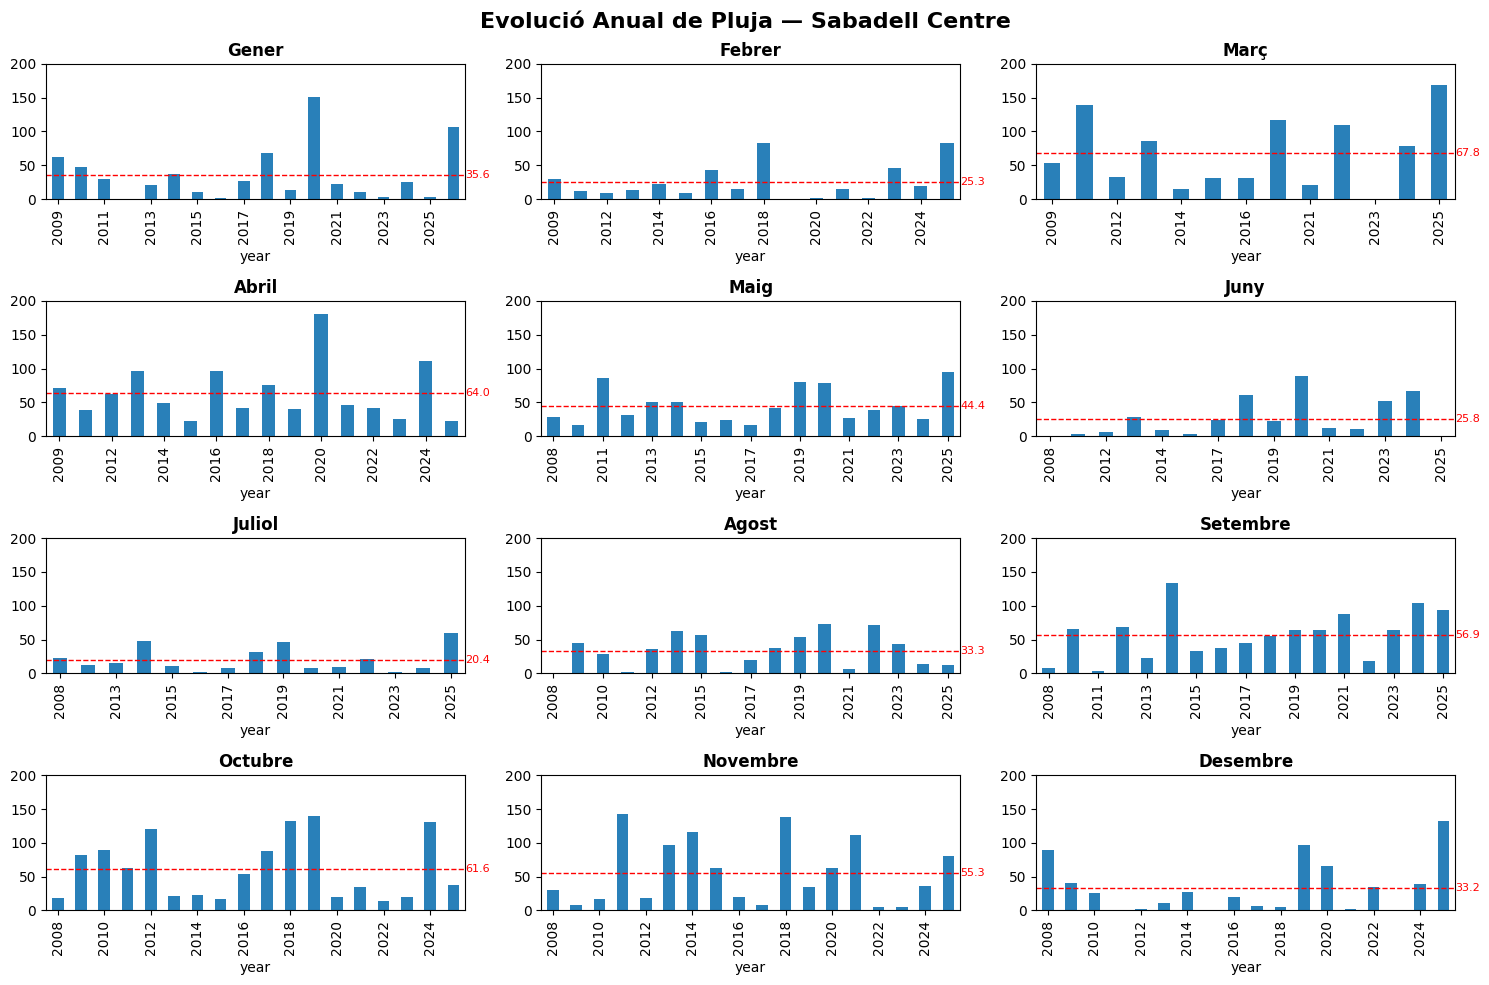

In [4]:
monthly_sbd_c = get_monthly_series(df_sbd_centre)
plot_monthly_grid(monthly_sbd_c, 'Sabadell Centre')

### 2.3 Mitjana Mensual de Pluja

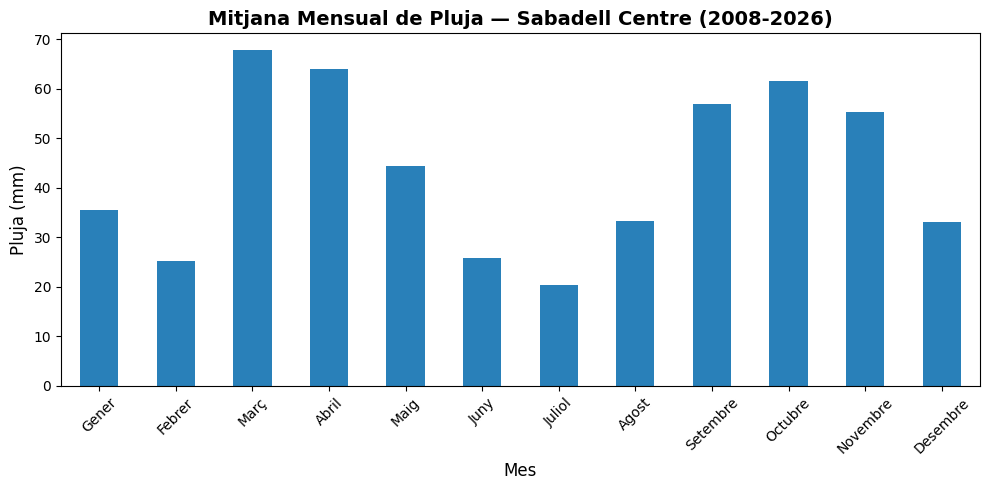

In [5]:
avg_sbd_c = plot_monthly_average(df_sbd_centre, 'Sabadell Centre', f"{df_sbd_centre['year'].min()}-{df_sbd_centre['year'].max()}")

## 3. Sabadell Nord (Parc Agrari)

### 3.1 Càrrega de Dades

In [6]:
url_sbd_nord = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Sbd_nord_daily.csv'
df_sbd_nord = load_station_data(url_sbd_nord)

print(f"Sabadell Nord: {df_sbd_nord['year'].min()}–{df_sbd_nord['year'].max()}")
print(f"Total registres: {len(df_sbd_nord):,}")

Sabadell Nord: 2008–2026
Total registres: 6,369


### 3.2 Evolució Anual per Mes

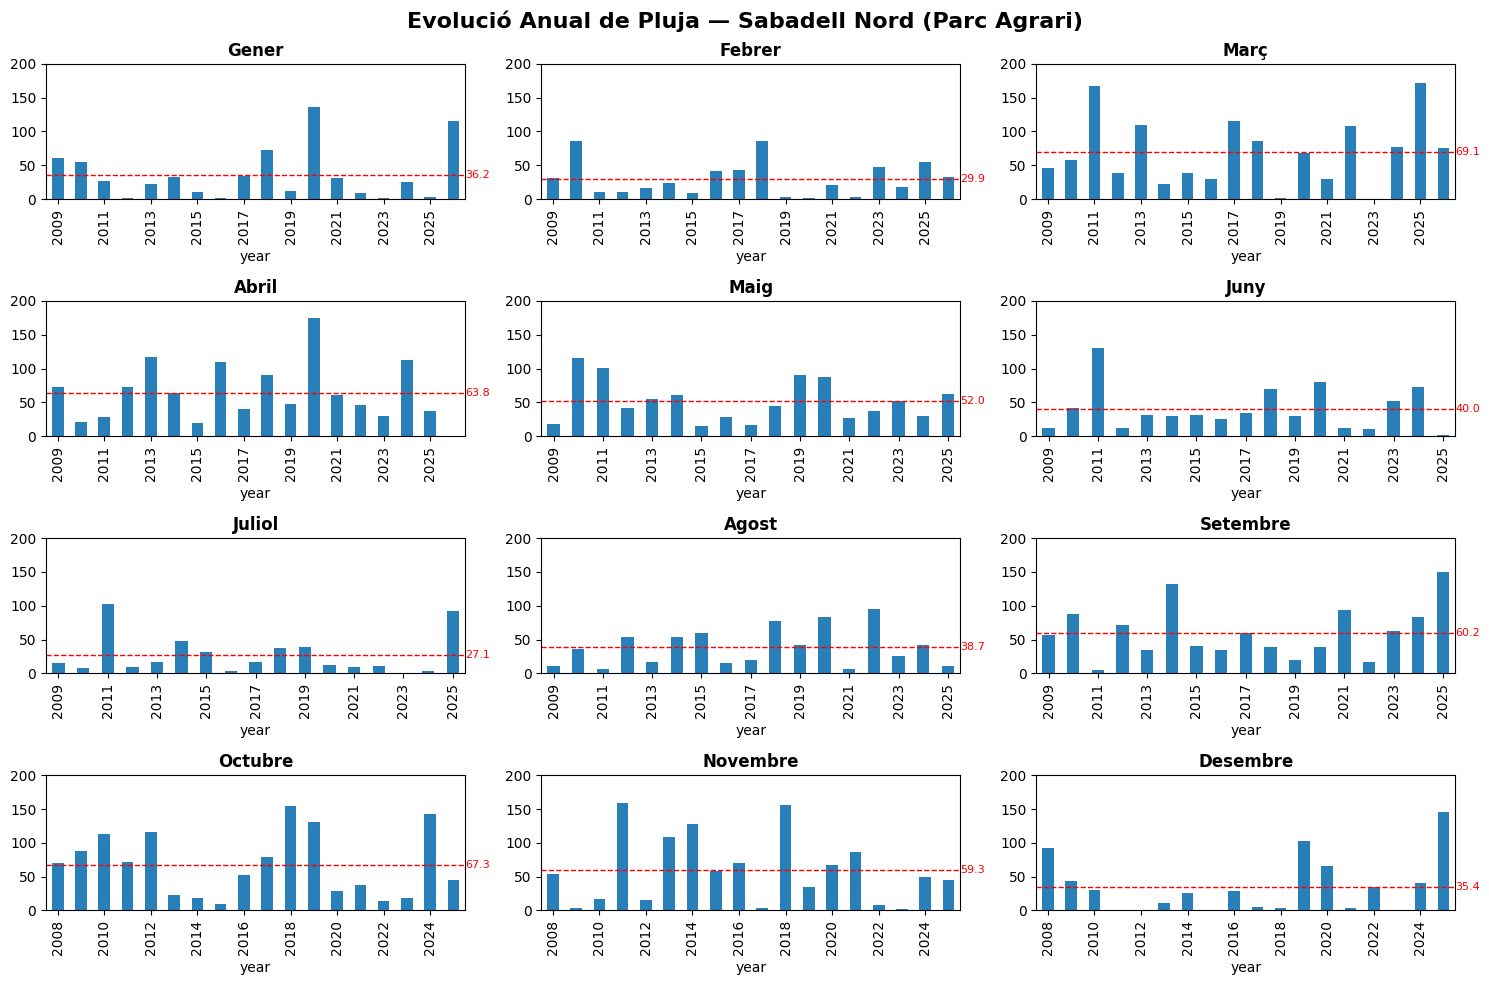

In [7]:
monthly_sbd_n = get_monthly_series(df_sbd_nord)
plot_monthly_grid(monthly_sbd_n, 'Sabadell Nord (Parc Agrari)')

### 3.3 Mitjana Mensual de Pluja

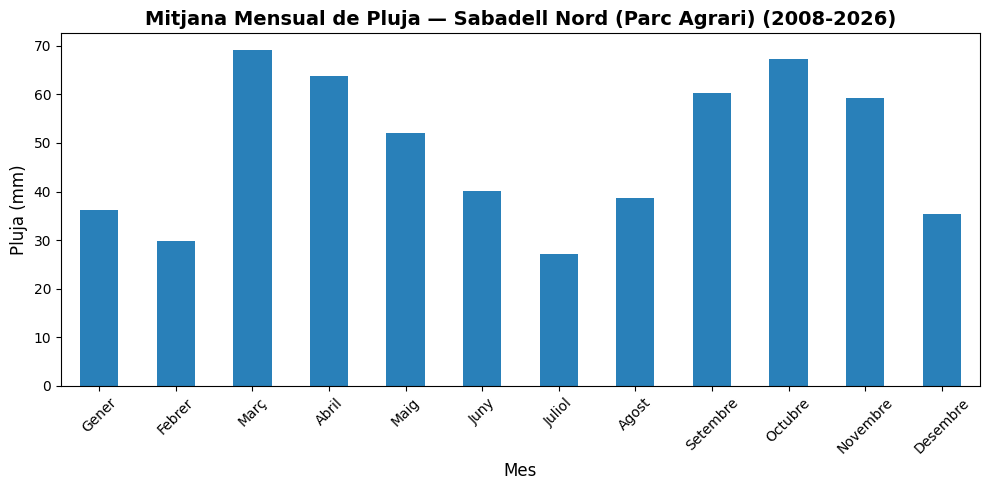

In [8]:
avg_sbd_n = plot_monthly_average(df_sbd_nord, 'Sabadell Nord (Parc Agrari)', f"{df_sbd_nord['year'].min()}-{df_sbd_nord['year'].max()}")

## 4. Vacarisses

### 4.1 Càrrega de Dades

In [9]:
url_vac = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Vacarisses_daily.csv'
df_vac = load_station_data(url_vac)

print(f"Vacarisses: {df_vac['year'].min()}–{df_vac['year'].max()}")
print(f"Total registres: {len(df_vac):,}")

Vacarisses: 1996–2026
Total registres: 10,960


### 4.2 Evolució Anual per Mes

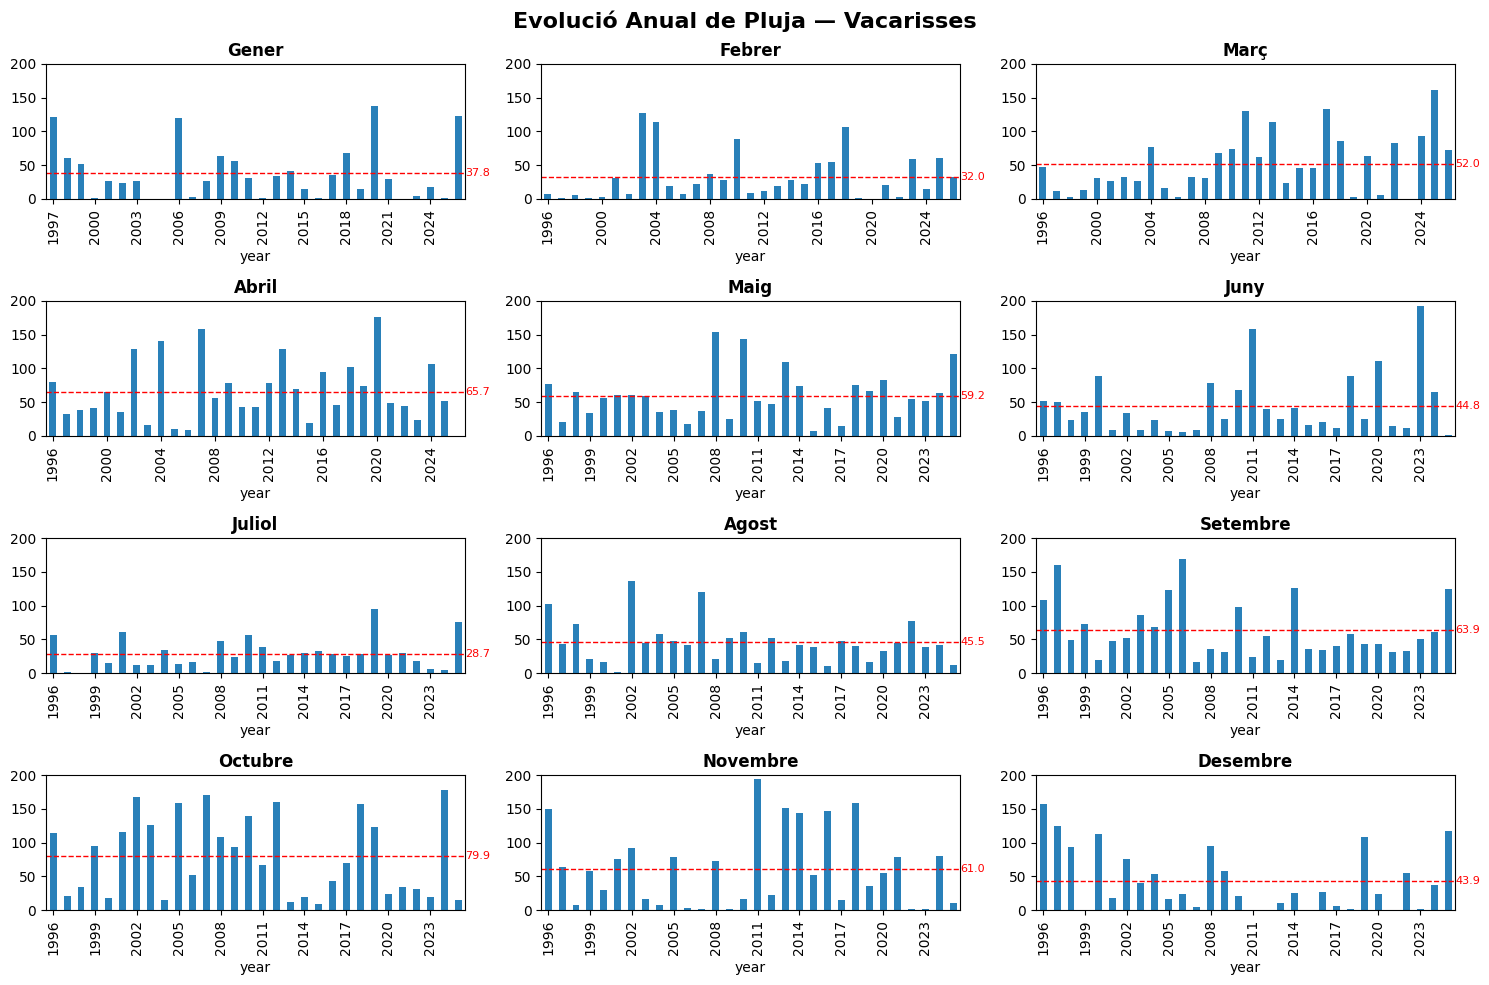

In [10]:
monthly_vac = get_monthly_series(df_vac)
plot_monthly_grid(monthly_vac, 'Vacarisses')

### 4.3 Mitjana Mensual de Pluja

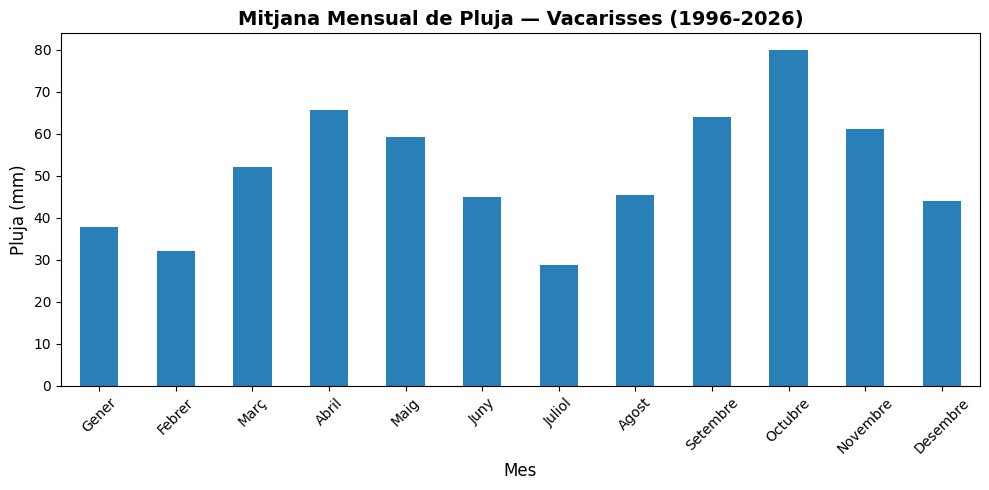

In [11]:
avg_vac = plot_monthly_average(df_vac, 'Vacarisses', f"{df_vac['year'].min()}-{df_vac['year'].max()}")

## 5. Comparació i Conclusions

### 5.1 Mesos Més Plujosos (Comparació)

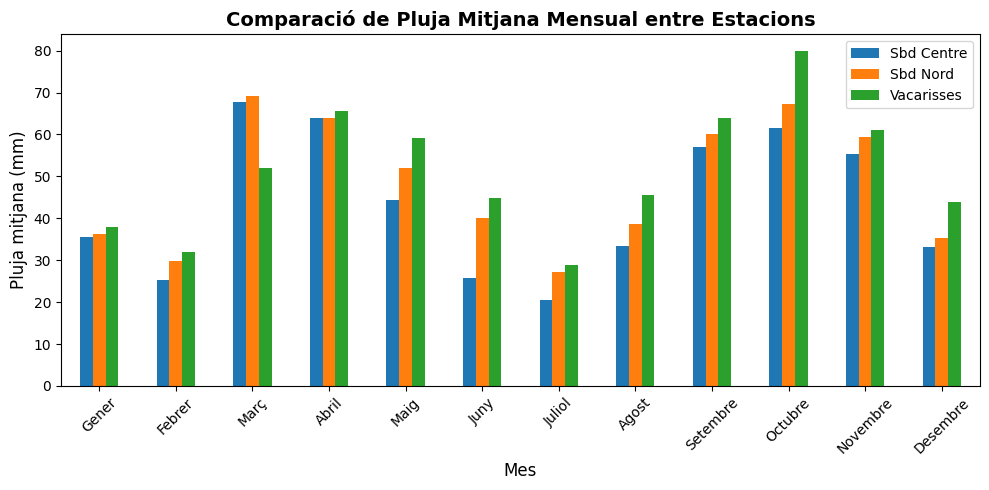

In [12]:
comparison = pd.DataFrame({
    'Sbd Centre': avg_sbd_c,
    'Sbd Nord': avg_sbd_n,
    'Vacarisses': avg_vac
})

fig, ax = plt.subplots(figsize=(10, 5))
comparison.plot.bar(ax=ax)
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Pluja mitjana (mm)', fontsize=12)
ax.set_title('Comparació de Pluja Mitjana Mensual entre Estacions', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [13]:
print("\nMesos més plujosos per estació:")
for name, avg in [('Sabadell Centre', avg_sbd_c), ('Sabadell Nord', avg_sbd_n), ('Vacarisses', avg_vac)]:
    top3 = avg.nlargest(3)
    print(f"\n  {name}:")
    for month, val in top3.items():
        print(f"    {month}: {val:.1f} mm")


Mesos més plujosos per estació:

  Sabadell Centre:
    Març: 67.8 mm
    Abril: 64.0 mm
    Octubre: 61.6 mm

  Sabadell Nord:
    Març: 69.1 mm
    Octubre: 67.3 mm
    Abril: 63.8 mm

  Vacarisses:
    Octubre: 79.9 mm
    Abril: 65.7 mm
    Setembre: 63.9 mm


### 5.2 Conclusions

Segons els gràfics d'evolució anual, **no hi ha una tendència clara** d'augment o disminució de les pluges al llarg dels anys a cap de les tres estacions.

Tot i això, es pot observar que **hi ha mesos amb més pluja que altres** de manera consistent entre les tres estacions, indicant un patró estacional marcat.